# Load and explore the data

## Import libraries

In [76]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# seaborn is a data visualization library built on matplotlib
import seaborn as sns
# set the plotting style
sns.set_style("whitegrid")

# Model preprocessing
from sklearn.preprocessing import StandardScaler

# Modeling
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Model metrics and analysis
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.anova import anova_lm

## Load Data Set

#### Load the EdGap Data Set

In [4]:
edgap = pd.read_excel('https://github.com/princenewman02/Education-/raw/refs/heads/main/Data/EdGap_Data.xlsx', dtype={'NCESSCH School ID': object}
)


/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


In [5]:
school_information = pd.read_csv(
    "/Users/princenewman/Projects/MSDS/Education/Data/ccd_sch_029_1617_w_1a_11212017 (1).csv", 
    encoding="unicode_escape", 
    low_memory=False
)

## Explore the contents of the data set

#### Start by looking at the head of each data frame


In [6]:
edgap.head()

,NCESSCH School ID,CT Unemployment Rate,CT Pct Adults with College Degree,CT Pct Childre In Married Couple Family,CT Median Household Income,School ACT average (or equivalent if SAT score),School Pct Free and Reduced Lunch
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641


#### School information data set

In [7]:
school_information.head()

,SCHOOL_YEAR,FIPST,STATENAME,ST,SCH_NAME,LEA_NAME,STATE_AGENCY_NO,UNION,ST_LEAID,LEAID,...,G_10_OFFERED,G_11_OFFERED,G_12_OFFERED,G_13_OFFERED,G_UG_OFFERED,G_AE_OFFERED,GSLO,GSHI,LEVEL,IGOFFERED
0,2016-2017,1,ALABAMA,AL,Sequoyah Sch - Chalkville Campus,Alabama Youth Services,01,NaN,AL-210,0100002,...,Yes,Yes,Yes,No,No,No,07,12,High,As reported
1,2016-2017,1,ALABAMA,AL,Camps,Alabama Youth Services,01,NaN,AL-210,0100002,...,Yes,Yes,Yes,No,No,No,07,12,High,As reported
2,2016-2017,1,ALABAMA,AL,Det Ctr,Alabama Youth Services,01,NaN,AL-210,0100002,...,Yes,Yes,Yes,No,No,No,07,12,High,As reported
3,2016-2017,1,ALABAMA,AL,Wallace Sch - Mt Meigs Campus,Alabama Youth Services,01,NaN,AL-210,0100002,...,Yes,Yes,Yes,No,No,No,07,12,High,As reported
4,2016-2017,1,ALABAMA,AL,McNeel Sch - Vacca Campus,Alabama Youth Services,01,NaN,AL-210,0100002,...,Yes,Yes,Yes,No,No,No,07,12,High,As reported


In [8]:
pd.set_option('display.max_columns', None)
school_information.head()

,SCHOOL_YEAR,FIPST,STATENAME,ST,SCH_NAME,LEA_NAME,STATE_AGENCY_NO,UNION,ST_LEAID,LEAID,ST_SCHID,NCESSCH,SCHID,MSTREET1,MSTREET2,MSTREET3,MCITY,MSTATE,MZIP,MZIP4,LSTREET1,LSTREET2,LSTREET3,LCITY,LSTATE,LZIP,LZIP4,PHONE,WEBSITE,SY_STATUS,SY_STATUS_TEXT,UPDATED_STATUS,UPDATED_STATUS_TEXT,EFFECTIVE_DATE,SCH_TYPE_TEXT,SCH_TYPE,RECON_STATUS,OUT_OF_STATE_FLAG,CHARTER_TEXT,CHARTAUTH1,CHARTAUTHN1,CHARTAUTH2,CHARTAUTHN2,NOGRADES,G_PK_OFFERED,G_KG_OFFERED,G_1_OFFERED,G_2_OFFERED,G_3_OFFERED,G_4_OFFERED,G_5_OFFERED,G_6_OFFERED,G_7_OFFERED,G_8_OFFERED,G_9_OFFERED,G_10_OFFERED,G_11_OFFERED,G_12_OFFERED,G_13_OFFERED,G_UG_OFFERED,G_AE_OFFERED,GSLO,GSHI,LEVEL,IGOFFERED
0,2016-2017,1,ALABAMA,AL,Sequoyah Sch - Chalkville Campus,Alabama Youth Services,01,NaN,AL-210,0100002,AL-210-0020,1.000020e+10,100277.0,P O Box 9486,NaN,NaN,Birmingham,AL,35220,NaN,1000 Industrial School Road,NaN,NaN,Birmingham,AL,35220,NaN,(205)680-8574,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported
1,2016-2017,1,ALABAMA,AL,Camps,Alabama Youth Services,01,NaN,AL-210,0100002,AL-210-0050,1.000020e+10,101667.0,P O Box 66,NaN,NaN,Mt Meigs,AL,36057,NaN,1601 County Rd. 57,NaN,NaN,Prattville,AL,36067,NaN,(334)215-3850,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported
2,2016-2017,1,ALABAMA,AL,Det Ctr,Alabama Youth Services,01,NaN,AL-210,0100002,AL-210-0060,1.000020e+10,101670.0,P O Box 66,NaN,NaN,Mt Meigs,AL,36057,NaN,2109 Bashi Rd Bldg 509,NaN,NaN,Thomasville,AL,36784,NaN,(334)215-3850,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported
3,2016-2017,1,ALABAMA,AL,Wallace Sch - Mt Meigs Campus,Alabama Youth Services,01,NaN,AL-210,0100002,AL-210-0030,1.000020e+10,101705.0,P O Box 66,NaN,NaN,Mount Meigs,AL,36057,NaN,1000 Industrial School Road,NaN,NaN,Mount Meigs,AL,36057,NaN,(334)215-6039,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported
4,2016-2017,1,ALABAMA,AL,McNeel Sch - Vacca Campus,Alabama Youth Services,01,NaN,AL-210,0100002,AL-210-0040,1.000020e+10,101706.0,8950 Roebuck Blvd,NaN,NaN,Birmingham,AL,35206,NaN,8950 Roebuck Blvd,NaN,NaN,Birmingham,AL,35206,NaN,(205)838-4981,http://www.dys.alabama.gov,1,Open,1,Open,03/03/2010,Alternative School,4,No,No,No,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,07,12,High,As reported


#### Use the info method to check the data types, size of the data frame, and numbers of missing values

In [9]:
edgap.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7986 entries, 0 to 7985
Data columns (total 7 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   NCESSCH School ID                                7986 non-null   object 
 1   CT Unemployment Rate                             7972 non-null   float64
 2   CT Pct Adults with College Degree                7973 non-null   float64
 3   CT Pct Childre In Married Couple Family          7961 non-null   float64
 4   CT Median Household Income                       7966 non-null   float64
 5   School ACT average (or equivalent if SAT score)  7986 non-null   float64
 6   School Pct Free and Reduced Lunch                7986 non-null   float64
dtypes: float64(6), object(1)
memory usage: 436.9+ KB


#### School information data set

In [10]:
school_information.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102183 entries, 0 to 102182
Data columns (total 65 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   SCHOOL_YEAR          102183 non-null  object 
 1   FIPST                102183 non-null  int64  
 2   STATENAME            102183 non-null  object 
 3   ST                   102183 non-null  object 
 4   SCH_NAME             102183 non-null  object 
 5   LEA_NAME             102183 non-null  object 
 6   STATE_AGENCY_NO      102183 non-null  object 
 7   UNION                2533 non-null    float64
 8   ST_LEAID             102183 non-null  object 
 9   LEAID                102183 non-null  object 
 10  ST_SCHID             102183 non-null  object 
 11  NCESSCH              102181 non-null  float64
 12  SCHID                102181 non-null  float64
 13  MSTREET1             102181 non-null  object 
 14  MSTREET2             1825 non-null    object 
 15  MSTREET3         

#### Summary
1. The School information data set is much larger than the EdGap data set. Clearly the EdGap data set does not  all schools.
2. There are missing values in each data set.
3. Each data set is in a tidy, or long format.
4. The data types for the variables of interest look correct, but the school identifier is an object in the EdGap data set and a float64 in the school information data set. 

## Are the data suitable for answering the question? 
#### We want to perform quick exploratory data analysis to determine whether the data are sufficient to answer our question. If the data are not sufficient, we do not want to waste time doing anything that will not be productive.

#### Make a pair plot to explore relationships betweeen the variables

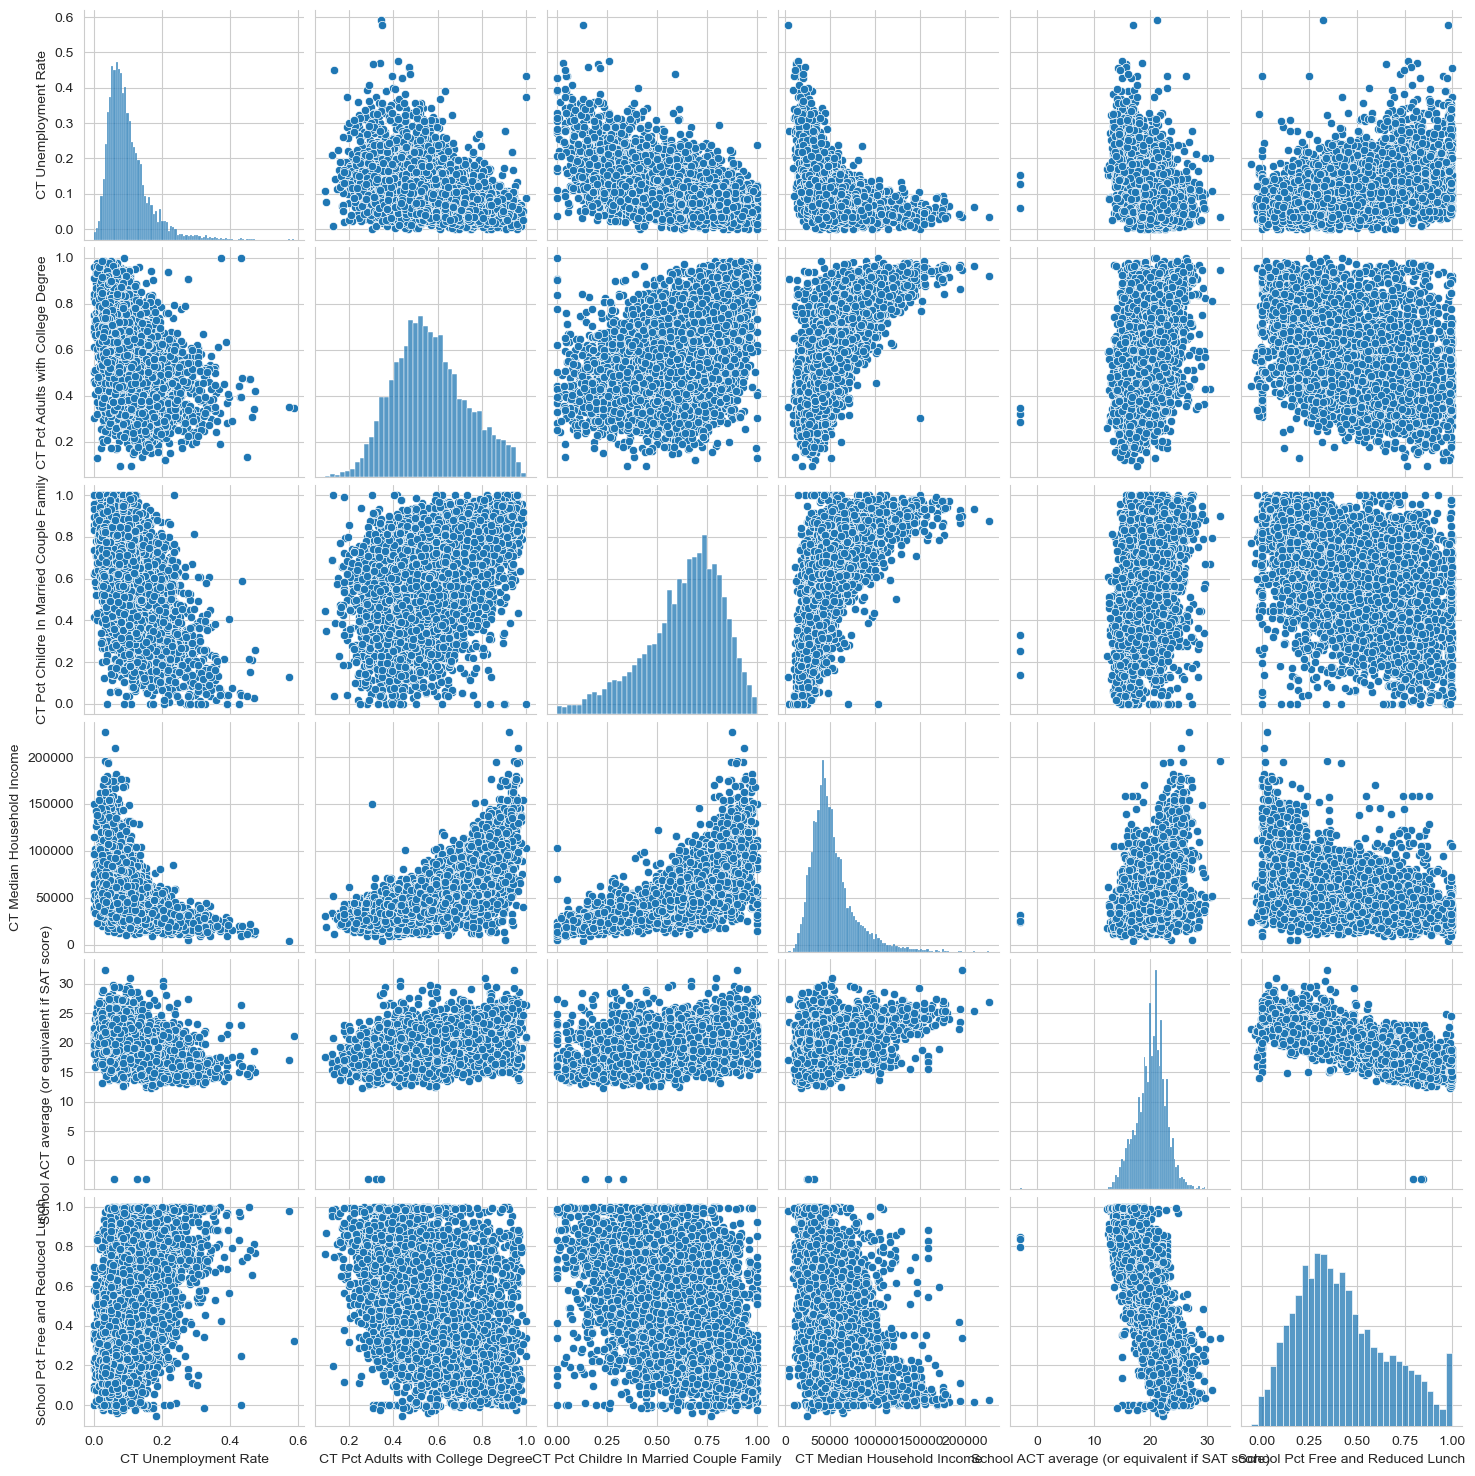

In [11]:
sns.pairplot(
    edgap.drop(columns="NCESSCH School ID"));
plt.show()

#### Add regression lines and format the pair plot

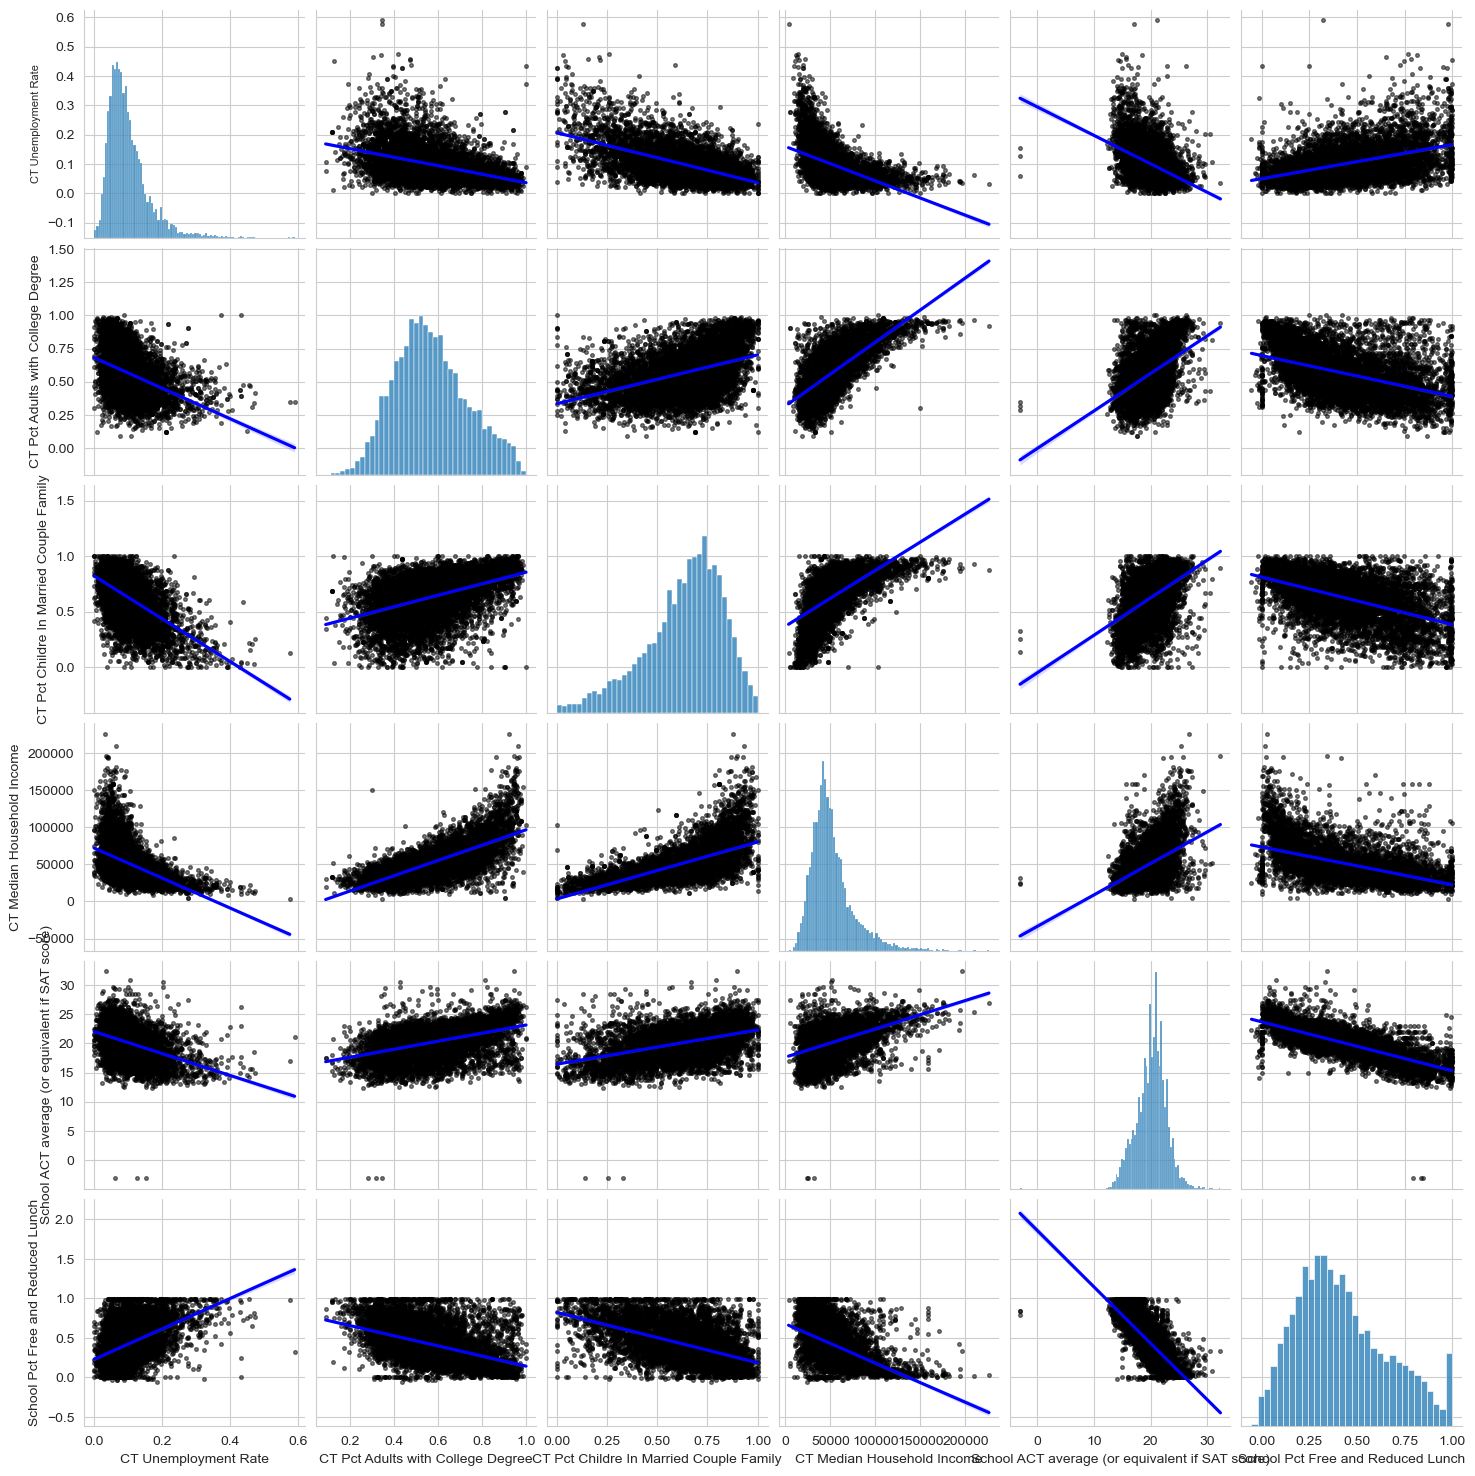

In [12]:
fig = sns.pairplot(
    edgap.drop(columns="NCESSCH School ID"),
    kind="reg",
    plot_kws={
        "line_kws": {"color": "blue"},
        "scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    }, 
)

for ax in  fig.axes.flat: 
    if ax.get_xlabel() == 'CT Median Household Income':
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) # Apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right') # X-axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8) # Y-axis label size

    # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

    plt.show()

#### Plot a Single row

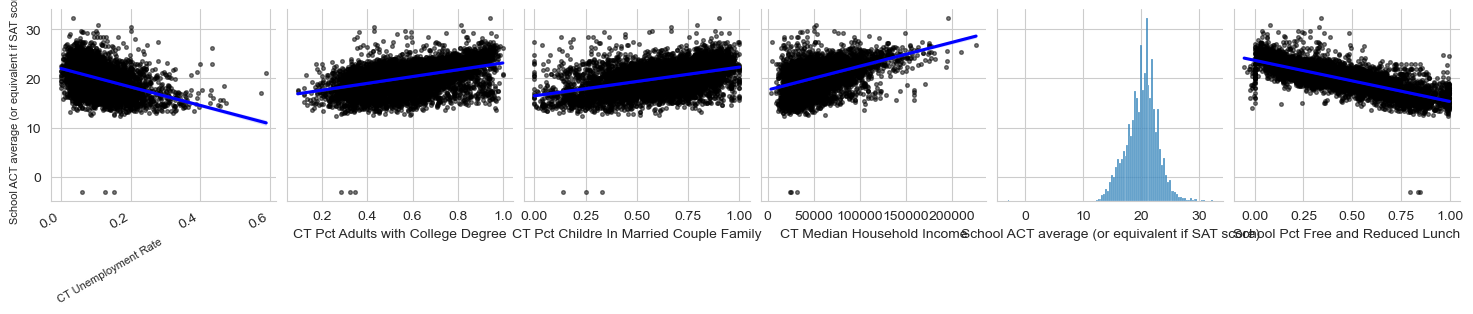

In [13]:
fig = sns.pairplot(
    edgap.drop(columns="NCESSCH School ID"),
    y_vars=['School ACT average (or equivalent if SAT score)'],
    kind="reg",
    plot_kws={
        "line_kws": {"color": "blue"},
        "scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    }, 
)

for ax in  fig.axes.flat: 
    if ax.get_xlabel() == 'CT Median Household Income':
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) # Apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right') # X-axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8) # Y-axis label size

    # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

    plt.show()

#### Summary
1. There appears to be a relationship between the socioeconomic variables and the ACT score
2. There are some out-of-range ACT and percent lunch values that will need to be dealt with
3. We should have confidence that it is worthwhile to spend time preparing the data for analysis

## Data Preparation

### Select relevant subsets of the data 
##### The school information data set contains many columns. We will only keep the year, school identity, location, and school type information.

##### Keeep the columns SCHOOL_YEEAR, NCESSCH, LSTATE, LZIP, SCH_TYPEE_TEXT, LEVEL, CHARTER_TEXT

In [15]:
school_information = school_information[
['SCHOOL_YEAR', 'NCESSCH', 'LSTATE', 'LZIP', 'SCH_TYPE_TEXT', 'LEVEL', 'CHARTER_TEXT']
]

In [16]:
school_information.head()

,SCHOOL_YEAR,NCESSCH,LSTATE,LZIP,SCH_TYPE_TEXT,LEVEL,CHARTER_TEXT
0,2016-2017,1.000020e+10,AL,35220,Alternative School,High,No
1,2016-2017,1.000020e+10,AL,36067,Alternative School,High,No
2,2016-2017,1.000020e+10,AL,36784,Alternative School,High,No
3,2016-2017,1.000020e+10,AL,36057,Alternative School,High,No
4,2016-2017,1.000020e+10,AL,35206,Alternative School,High,No


## Rename columns: for edgap
We will rename the columns to follow best practices of style and being informative. We can do this before or after joining the data sets. We will do it before joining the data sets to make it obvious that the key has the same name in each data set (this isn't required, but it makes your work easier to read).

In [17]:
edgap = edgap.rename(
columns={
    "NCESSCH School ID": "id",
    "CT Pct Adults with College Degree": "percent_college",
    "CT Unemployment Rate": "rate_unemployment",
    "CT Pct Children In Married Couple Family": "percent_married",
    "CT Median Household Income": "median_income", 
    "School ACT average (or equivalent if SAT score)": "average_act",
    "School Pct Free and Reduced Lunch": "percent_lunch",
}
)

In [18]:
edgap.head()

,id,rate_unemployment,percent_college,CT Pct Childre In Married Couple Family,median_income,average_act,percent_lunch
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641


#### Rename column: School Information

In [19]:
school_information = school_information.rename(
columns={
    "SCHOOL_YEAR": "year",	
    "NCESSCH": "id",
    "LSTATE": "state",    
    "LZIP": "zip_code",
    "SCH_TYPE_TEXT": "scchool_type",	
    "LEVEL": "school_level", 	
    "CHARTER_TEXT": "charter"
}
)

In [20]:
school_information.head()

,year,id,state,zip_code,scchool_type,school_level,charter
0,2016-2017,1.000020e+10,AL,35220,Alternative School,High,No
1,2016-2017,1.000020e+10,AL,36067,Alternative School,High,No
2,2016-2017,1.000020e+10,AL,36784,Alternative School,High,No
3,2016-2017,1.000020e+10,AL,36057,Alternative School,High,No
4,2016-2017,1.000020e+10,AL,35206,Alternative School,High,No


#### Summary
1. We selected a subset of columns of the school information data set.
2. We renamed the columns for clarity and to follow formatting guidelines.
3. We are ready to join the data frames.

## Join Data frames
We want to join the DataFrames using the identity of the school as the key. The identity is given by the NCESSCH school identity.
The value is an object in the EdGap data set and a float64 in the school information data set.
We will cast the id column in the school_information DataFrame as an object.


In [22]:
school_information['id'] = school_information['id'].astype('object')

In [23]:
school_information.columns

Index(['year', 'id', 'state', 'zip_code', 'scchool_type', 'school_level',
       'charter'],
      dtype='object')

In [24]:
school_information.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102183 entries, 0 to 102182
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   year          102183 non-null  object
 1   id            102181 non-null  object
 2   state         102183 non-null  object
 3   zip_code      102183 non-null  object
 4   scchool_type  102181 non-null  object
 5   school_level  102179 non-null  object
 6   charter       102179 non-null  object
dtypes: object(7)
memory usage: 5.5+ MB


#### Join the data frames and call the result df.

In [25]:
df = edgap.merge(
    school_information, 
    how='left',
    on='id'
)

In [26]:
df.head()

,id,rate_unemployment,percent_college,CT Pct Childre In Married Couple Family,median_income,average_act,percent_lunch,year,state,zip_code,scchool_type,school_level,charter
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,DE,19804,Regular School,High,Yes
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412,2016-2017,DE,19709,Regular School,High,No
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816,2016-2017,DE,19709,Regular School,High,No
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960,2016-2017,DE,19958,Regular School,High,No
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641,2016-2017,DE,19934,Regular School,High,No


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7986 entries, 0 to 7985
Data columns (total 13 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id                                       7986 non-null   object 
 1   rate_unemployment                        7972 non-null   float64
 2   percent_college                          7973 non-null   float64
 3   CT Pct Childre In Married Couple Family  7961 non-null   float64
 4   median_income                            7966 non-null   float64
 5   average_act                              7986 non-null   float64
 6   percent_lunch                            7986 non-null   float64
 7   year                                     7898 non-null   object 
 8   state                                    7898 non-null   object 
 9   zip_code                                 7898 non-null   object 
 10  scchool_type                             7898 no

# Summary
1. We joined the data sets using the school id as the key
2. We first cast id as an object to have the same data type for the key in each data set
3. Wee used a left join to keeeo all EdGap data

# Quality Control 

#### There are natural bounds for the nummerical variables in the data set. Check the minimum and maximum values in each column. This is where we look for variables that are outside the range of possible values for a particular variable. 
We can use the describe() method to compute descriptive statistics

In [28]:
df.describe()   # helps compute descriptive stat

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,rate_unemployment,percent_college,CT Pct Childre In Married Couple Family,median_income,average_act,percent_lunch
count,7972.000000,7973.000000,7961.000000,7966.000000,7986.000000,7986.000000
mean,0.098730,0.568930,0.633440,52026.905222,20.181532,0.420651
std,0.058959,0.165704,0.196764,24228.057079,2.595201,0.239754
min,0.000000,0.091493,0.000000,3589.000000,-3.070818,-0.054545
25%,0.058655,0.450828,0.523810,36597.250000,18.600000,0.238501
50%,0.085649,0.554979,0.667594,46833.500000,20.400000,0.381570
75%,0.123376,0.676571,0.777135,61369.250000,21.910867,0.575447
max,0.590278,1.000000,1.000000,226181.000000,32.362637,0.998729


#### or use the min and max, as those are our focus

In [29]:
df.select_dtypes(include=['number']).agg(['min', 'max']).round(2)

,rate_unemployment,percent_college,CT Pct Childre In Married Couple Family,median_income,average_act,percent_lunch
min,0.00,0.09,0.0,3589.0,-3.07,-0.05
max,0.59,1.00,1.0,226181.0,32.36,1.00


#### we have now identified that we have some values that clearly are incorrect, we will set those values to NaN, using Numpy's NaN, eg average act that are negative

#### Set out-of-range values to NaN using np.nan

In [30]:
df.loc[df['percent_lunch'] < 0, 'percent_lunch'] = np.nan

In [31]:
df.loc[df['average_act'] < 0, 'average_act'] = np.nan

#### Check the types, levels, and charter startus of schools

In [32]:
df['scchool_type'].value_counts()

scchool_type
Regular School                 7885
Alternative School               10
Special Education School          2
Career and Technical School       1
Name: count, dtype: int64

In [33]:
df['school_level'].value_counts()

school_level
High            7230
Other            631
Not reported      35
Elementary         2
Name: count, dtype: int64

In [34]:
df['charter'].value_counts()

charter
No                7329
Yes                352
Not applicable     217
Name: count, dtype: int64

#### Keep only the high school, these are the schools where its appropriate to be taking the ACT 

In [35]:
df = df.loc[df['school_level'] == 'High'] # reassigned our df to keep only those rows where the school leveel is high

#### Check for any duplicated rows

In [36]:
df.duplicated().sum()

np.int64(0)

#### It is possible that there are incorrectly recorded values in the data set, but we will not go that far in this examle

# Identify missing values 
How many values of each variable are missing?

In [37]:
df.isna().sum().to_frame(name='Number of Missing Values')

,Number of Missing Values
id,0
rate_unemployment,12
percent_college,11
CT Pct Childre In Married Couple Family,20
median_income,16
average_act,3
percent_lunch,20
year,0
state,0
zip_code,0


#### What percentage of values of each variable are missing? 

In [38]:
percent_missing =  df.isna().mean().round(4) * 100

In [39]:
percent_missing.to_frame(name='Percent Missing Values')

,Percent Missing Values
id,0.00
rate_unemployment,0.17
percent_college,0.15
CT Pct Childre In Married Couple Family,0.28
median_income,0.22
average_act,0.04
percent_lunch,0.28
year,0.00
state,0.00
zip_code,0.00


#### What states do we have data from?

In [40]:
df['state'].value_counts()

state
TX    913
OH    654
IL    564
PA    543
MI    498
NC    407
FL    404
GA    367
WI    351
NJ    341
MO    337
IN    321
NY    295
TN    265
WA    263
MA    253
KY    198
LA    194
WY     38
DE     24
Name: count, dtype: int64

In [41]:
df['state'].nunique()

20

#### Plot the results on a map

In [42]:
import plotly.offline as po
import plotly.graph_objs as pg

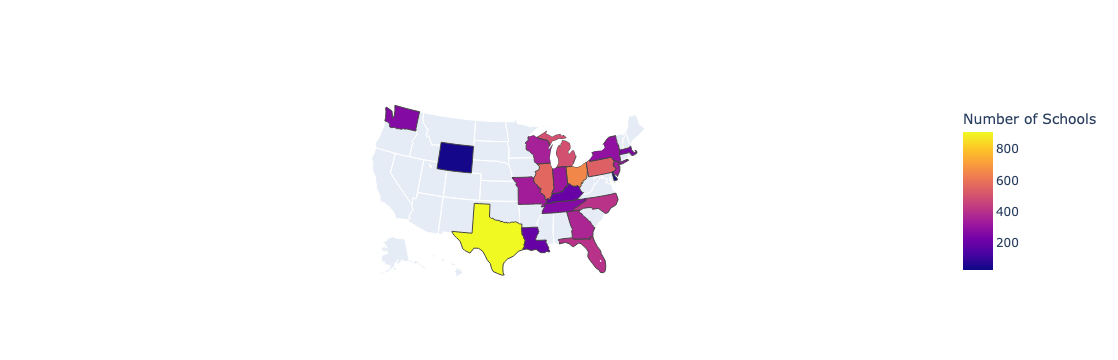

In [43]:
layout = dict(
    geo={"scope": "usa"}, coloraxis_colorbar=dict(title="Number of Schools")
)

data = dict(
    type="choropleth",
    locations=df["state"].value_counts().index, 
    locationmode="USA-states",
    z=df["state"].value_counts().values, 
    coloraxis="coloraxis",
)

x = pg.Figure(data=[data], layout=layout)

po.iplot(x)

#### We are missing a large amount of USA data due to omission. This is not evident by exammining NaN values in the data set. 
We could obtain this info from public  records, but we will not do that here. 

#### Drop the rows where the average ACT score is missing

In [46]:
df = df.dropna(subset=['average_act'])

In [47]:
df.isna().sum().to_frame(name='Number of Missing Values')

,Number of Missing Values
id,0
rate_unemployment,12
percent_college,11
CT Pct Childre In Married Couple Family,20
median_income,16
average_act,0
percent_lunch,20
year,0
state,0
zip_code,0


#### If we drop rows that have NaNs for any socioeconomic variables, then we will negatively affect our analysis using the variables where data were present. So, we will not drop the rows in this dara set that are missing the socioeconomic variables.We will impute the missing values

# Summary 
1. We set out-of-range values to NaN and will impute them
2. We kept only high schools.
3. We removed schools where we do not have the ACT score
4. Many schools are missing from the data by omission
5. We will immpute missing values of socioeconomic variables

# Data Imputation

#### Define the predictor variables to be rate_unemployment, percent_college, percent_married, median_income, percent_lunch, state, and charter. 

In [48]:
predictor_variables = [
    'rate_unemployment', 
    'percent_college', 
    'percent_married', 
    'median_income', 
    'percent_lunch', 
    'state', 
    'charter'
]

#### Use the iterative immputer to relace the missing values in the columns corresponding to predictor variables in the analysis

In [49]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [50]:
imputer = IterativeImputer()

#### Fit the imputer with the numerical predictor variables (this can include dummies for categorical variables).
Define the columns you want to use in the imputation process

In [51]:
numerical_predictors = df[predictor_variables].select_dtypes(include='number').columns.to_list()
print(numerical_predictors)

KeyError: "['percent_married'] not in index"

In [52]:
df = df.rename(columns={"CT Pct Childre In Married Couple Family": "percent_married"})  # renaming the column to resolve error 

In [53]:
numerical_predictors = df[predictor_variables].select_dtypes(include='number').columns.to_list()
print(numerical_predictors)

['rate_unemployment', 'percent_college', 'percent_married', 'median_income', 'percent_lunch']


#### Fit the imputer

In [56]:
imputer.fit(df.loc[:, numerical_predictors])

IterativeImputer()

In [57]:
df.loc[:, numerical_predictors] = imputer.transform(df.loc[:, numerical_predictors])

#### Check for missing values

In [58]:
df.isna().sum().to_frame(name='Number of Missing Values')

,Number of Missing Values
id,0
rate_unemployment,0
percent_college,0
percent_married,0
median_income,0
average_act,0
percent_lunch,0
year,0
state,0
zip_code,0


#### Export a clean data set

In [62]:
df.to_csv(
    'education_clean.csv',
    encoding='utf-8-sig',
    index=False
)

# Summary
1. We used an iterative imputer to estimate missing values of numerical predictor variables
2. We saved the clean data frame as a csv file

# Load clean data

In [65]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/princenewman02/Education/refs/heads/main/Code/education_clean.csv'
)

In [84]:
df.head()

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,state,zip_code,scchool_type,school_level,charter
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,DE,19804,Regular School,High,Yes
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412,2016-2017,DE,19709,Regular School,High,No
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816,2016-2017,DE,19709,Regular School,High,No
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960,2016-2017,DE,19958,Regular School,High,No
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641,2016-2017,DE,19934,Regular School,High,No


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7227 entries, 0 to 7226
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 7227 non-null   int64  
 1   rate_unemployment  7227 non-null   float64
 2   percent_college    7227 non-null   float64
 3   percent_married    7227 non-null   float64
 4   median_income      7227 non-null   float64
 5   average_act        7227 non-null   float64
 6   percent_lunch      7227 non-null   float64
 7   year               7227 non-null   object 
 8   state              7227 non-null   object 
 9   zip_code           7227 non-null   int64  
 10  scchool_type       7227 non-null   object 
 11  school_level       7227 non-null   object 
 12  charter            7227 non-null   object 
dtypes: float64(6), int64(2), object(5)
memory usage: 734.1+ KB


# Load new finance data 

In [217]:
url = 'https://raw.githubusercontent.com/princenewman02/Education/refs/heads/main/Data/school_finance_2016_17.csv'

school_fin = pd.read_csv(
    url,
    skiprows=5,        # skips the first 5 metadata lines
    on_bad_lines='skip'  # skips any rows with inconsistent columns
)

In [218]:
school_fin.head()

,Agency Name,State Name [District] Latest available year,State Name [District] 2016-17,Agency Name [District] 2016-17,Agency ID - NCES Assigned [District] Latest available year,Total Current Expenditures (TCURELSC) per Pupil (V33) [District Finance] 2016-17,Fall Membership (V33) [District Finance] 2016-17
0,21ST CENTURY CHARTER SCH OF GARY,Indiana,INDIANA,21st Century Charter Sch of Gary,1800046.0,8386,888
1,21ST CENTURY CYBER CS,Pennsylvania,PENNSYLVANIA,21st Century Cyber CS,4200091.0,12425,961
2,A CENTER FOR CREATIVE EDUCATION (79457),Arizona,ARIZONA,A Center for Creative Education,400328.0,7516,64
3,A E R O SPEC EDUC COOP,Illinois,ILLINOIS,A E R O Spec Educ Coop,1700024.0,†,†
4,A W BEATTIE CAREER CENTER,Pennsylvania,PENNSYLVANIA,A W Beattie Career Center,4280010.0,†,†


#### check data types, size of the data frame, and numbers of missing values

In [219]:
school_fin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18472 entries, 0 to 18471
Data columns (total 7 columns):
 #   Column                                                                            Non-Null Count  Dtype  
---  ------                                                                            --------------  -----  
 0   Agency Name                                                                       18472 non-null  object 
 1   State Name [District] Latest available year                                       18468 non-null  object 
 2   State Name [District] 2016-17                                                     18468 non-null  object 
 3   Agency Name [District] 2016-17                                                    18468 non-null  object 
 4   Agency ID - NCES Assigned [District] Latest available year                        18468 non-null  float64
 5   Total Current Expenditures (TCURELSC) per Pupil (V33) [District Finance] 2016-17  18468 non-null  object 
 6  

# Summary
1. Merged Data (df) Completeness: The cleaned df (7,227 entries) is complete (no missing values in any column), confirming a successful initial merge and cleanup process.

2. New Data Size: The district_fin dataset is much larger (18,472 entries) than the merged df, indicating a likely need for an inner join to only keep finance data for schools/districts present in df.

3. District Finance Data Missing Values: district_fin has a negligible number of missing values (4 entries) in key columns like Agency ID and financial metrics. These can be safely dropped or handled with minimal impact.

4. Data Type Inconsistencies for Merging: The identifier columns are mismatched: df['id'] is int64, while district_fin['Agency ID...'] is float64. We'll have to convert the float64 ID column in district_fin to an integer type before attempting the final merge.

5. Key Financial Metrics Need Cleaning: The crucial financial columns (Expenditures and Membership) are incorrectly stored as the object dtype. We need to clean and convert these columns to a numeric type (e.g., float64) to remove non-numeric characters (like footnotes or special symbols) and enable analysis.

## Data Preparation

The central challenge is merging these datasets despite their different levels of aggregation, as the school data uses individual school identifiers while the finance data uses district-level NCES codes. 

To resolve this, we will 
1. standardize our key identifiers by converting IDs to strings, extracting the district codes from the school NCES IDs (the part we’ll use to join later) which embed district codes in their first seven digits, allowing us to map each school to its corresponding district.

2. We will then verify lengths, uniqueness, and match rates. Review the match summary and decision output to confirm that our extracted district IDs properly align with those in our finance dataset.

3. Then rename your columns: Once we’ve confirmed everything matches and are confident about the structure, we can safely rename columns for readability. fyi: Renaming before matching sometimes causes confusion (e.g., renaming district_id_str to something short like dist_id might break the merge if we forget to update that reference in our code).

4. Merge Data sets: After verifying the match rate, we will perform a left join to merge district financial data to each school record, preserving the school-level granularity needed to examine how both socioeconomic conditions and district spending relate to student achievement outcomes. 

This approach avoids the loss of analytical precision that would result from state-level aggregation while enabling us to incorporate critical financial variables into the predictive model.

### Select relevant subsets of the data 
##### The school finance data set contains columns already available in the df data. We will only keep the State Name [District] Latest available year, Total Current Expenditures (TCURELSC), the Fall Membership (V33) 2016-17. 

##### Keep the columns State Name [District] Latest available year, Total Current Expenditures (TCURELSC), the Fall Membership (V33) 2016-17

In [222]:
school_fin = school_fin[
['Agency ID - NCES Assigned [District] Latest available year',
       'Total Current Expenditures (TCURELSC) per Pupil (V33) [District Finance] 2016-17',
       'Fall Membership (V33) [District Finance] 2016-17']
]

In [223]:
school_fin.head()

,Agency ID - NCES Assigned [District] Latest available year,Total Current Expenditures (TCURELSC) per Pupil (V33) [District Finance] 2016-17,Fall Membership (V33) [District Finance] 2016-17
0,1800046.0,8386,888
1,4200091.0,12425,961
2,400328.0,7516,64
3,1700024.0,†,†
4,4280010.0,†,†


## Standard Key Identifiers
converting IDs to strings, extracting the district codes from the school NCES IDs (the part we’ll use to join later) which embed district codes in their first seven digits, allowing us to map each school to its corresponding district

In [224]:
# Fix ID formats before matching
# School data (df)

df['id_str'] = df['id'].astype(str).str.strip()  # ensure all strings
df['extracted_district_id'] = df['id_str'].str[:7]  # extract district portion

In [226]:
# District finance data
# Convert float IDs to integers (if safe) and then to strings
district_fin['district_id_str'] = (
    district_fin['Agency ID - NCES Assigned [District] Latest available year']
    .fillna(0)  # handle missing values temporarily
    .astype(int)  # remove .0 decimals
    .astype(str)  # convert to string
    .str.zfill(7)  # ensure 7 digits if leading zeros matter
)

In [227]:
display(pd.DataFrame({
    'Dataset': ['School Data', 'District Finance Data'],
    'Column': ['extracted_district_id', 'district_id_str'],
    'Dtype': [df['extracted_district_id'].dtype, district_fin['district_id_str'].dtype]
}))

,Dataset,Column,Dtype
0,School Data,extracted_district_id,object
1,District Finance Data,district_id_str,object


In [228]:
# Preview sample IDs
display(pd.DataFrame({
    'Sample School District IDs': df['extracted_district_id'].dropna().head(5).tolist(),
    'Sample Finance District IDs': district_fin['district_id_str'].dropna().head(5).tolist()
}))

,Sample School District IDs,Sample Finance District IDs
0,1000016,1800046
1,1000080,4200091
2,1000080,0400328
3,1000170,1700024
4,1000180,4280010


In [229]:
# Check for invalid or malformed IDs (non–7-digit numeric strings)
invalid_school_ids = df.loc[~df['extracted_district_id'].str.match(r'^\d{7}$', na=False), 'extracted_district_id']
invalid_finance_ids = district_fin.loc[~district_fin['district_id_str'].str.match(r'^\d{7}$', na=False), 'district_id_str']

In [230]:
display(pd.DataFrame({
    'Invalid ID Type': ['School District IDs', 'Finance District IDs'],
    'Invalid Count': [len(invalid_school_ids), len(invalid_finance_ids)]
}))

,Invalid ID Type,Invalid Count
0,School District IDs,0
1,Finance District IDs,0


In [231]:
# Quick overlap / match preview
common_ids = set(df['extracted_district_id']).intersection(set(district_fin['district_id_str']))
match_preview = list(common_ids)[:5]

In [232]:
display(pd.DataFrame({
    'Total Matching District IDs': [len(common_ids)],
    'Example Matching IDs': [match_preview if match_preview else 'None found']
}))

,Total Matching District IDs,Example Matching IDs
0,4741,"[4834440, 5504380, 5308460, 1706120, 4704200]"


## verify lengths, uniqueness, and match rates

#### Check match rate

In [235]:
df['district_match'] = df['extracted_district_id'].isin(district_fin['district_id_str'])

In [236]:
real_match_rate = df['district_match'].mean() * 100

In [237]:
real_match_rate

np.float64(100.0)

In [238]:
pd.DataFrame({
    'Match Rate': [f"{real_match_rate:.1f}%"],
    'Assessment': ["✅ High match rate - proceed with merge confidently"]
})

,Match Rate,Assessment
0,100.0%,✅ High match rate - proceed with merge confide...


In [239]:
# Verify ID lengths
df['id_length'] = df['extracted_district_id'].str.len()
finance_id_length = district_fin['district_id_str'].str.len()

In [240]:
length_summary = pd.DataFrame({
    'Dataset': ['School Data', 'Finance Data'],
    'Expected Length': [7, 7],
    'Min Length': [df['id_length'].min(), finance_id_length.min()],
    'Max Length': [df['id_length'].max(), finance_id_length.max()]
})

In [248]:
display(length_summary)

,Dataset,Expected Length,Min Length,Max Length
0,School Data,7,7,7
1,Finance Data,7,7,7


### Check uniqueness

In [249]:
uniqueness_summary = pd.DataFrame({
    'Dataset': ['School Data', 'Finance Data'],
    'Unique IDs': [df['extracted_district_id'].nunique(), district_fin['district_id_str'].nunique()],
    'Total IDs': [len(df), len(district_fin)]
})

In [250]:
display(uniqueness_summary)

,Dataset,Unique IDs,Total IDs
0,School Data,4741,7227
1,Finance Data,18469,18472


In [245]:
# School-level match rate
df['district_match'] = df['extracted_district_id'].isin(district_fin['district_id_str'])
school_match_rate = df['district_match'].mean() * 100  # percentage

In [246]:
if school_match_rate > 70:
    decision = "✅ EXCELLENT: High match rate - proceed with merge confidently"
elif school_match_rate > 30:
    decision = "⚠️ MODERATE: Acceptable match rate - proceed but expect some data loss"
else:
    decision = "❌ LOW: Poor match rate - consider alternative approaches"

In [251]:
display(pd.DataFrame({
    'School-Level Match Rate': [f"{school_match_rate:.1f}%"],
    'Assessment': [decision]
}))

,School-Level Match Rate,Assessment
0,100.0%,✅ EXCELLENT: High match rate - proceed with me...


### Rename columns for readability

In [252]:
district_fin_renamed = district_fin.rename(columns={
    'Agency ID - NCES Assigned [District] Latest available year': 'district_id',
    'Total Current Expenditures (TCURELSC) per Pupil (V33) [District Finance] 2016-17': 'exp_per_pupil',
    'Fall Membership (V33) [District Finance] 2016-17': 'enrollment'
})

In [253]:
# Clean numeric columns: convert to float, set suppressed/missing as NaN
for col in ['exp_per_pupil', 'enrollment']:
    district_fin_renamed[col] = pd.to_numeric(district_fin_renamed[col], errors='coerce')

In [254]:
# Clean district ID
district_fin_renamed['district_id_str'] = (
    district_fin_renamed['district_id']
        .fillna(0)
        .astype(int)
        .astype(str)
        .str.zfill(7)
)

In [255]:
district_fin_renamed.columns

Index(['Agency Name', 'State Name [District] Latest available year',
       'State Name [District] 2016-17', 'Agency Name [District] 2016-17',
       'district_id', 'exp_per_pupil', 'enrollment', 'district_id_str'],
      dtype='object')

In [256]:
district_fin_clean = district_fin_renamed[['district_id_str', 'exp_per_pupil', 'enrollment']]

In [260]:
district_fin_clean.head()

,district_id_str,exp_per_pupil,enrollment
0,1800046,8386.0,888.0
1,4200091,12425.0,961.0
2,0400328,7516.0,64.0
3,1700024,NaN,NaN
4,4280010,NaN,NaN


In [261]:
district_fin_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18472 entries, 0 to 18471
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   district_id_str  18472 non-null  object 
 1   exp_per_pupil    15936 non-null  float64
 2   enrollment       16655 non-null  float64
dtypes: float64(2), object(1)
memory usage: 433.1+ KB


## Merge dataframes

In [262]:
# Perform left join: attach district finance data to each school
merged_df = df.merge(
    district_fin_clean,
    how='left',
    left_on='extracted_district_id',
    right_on='district_id_str'
)

In [263]:
# Quick verification of merge
verification_df = pd.DataFrame({
    'Total Schools in Original df': [len(df)],
    'Total Rows in Merged df': [len(merged_df)],
    'Schools Missing Finance Data': [merged_df['exp_per_pupil'].isna().sum()]
})

In [264]:
display(verification_df)

,Total Schools in Original df,Total Rows in Merged df,Schools Missing Finance Data
0,7227,7227,306


In [266]:
# Preview merged dataset
merged_df.head()

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,state,zip_code,scchool_type,school_level,charter,id_str,extracted_district_id,district_match,id_length,district_id_str,exp_per_pupil,enrollment
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,DE,19804,Regular School,High,Yes,100001600143,1000016,True,7,1000016,9344.0,584.0
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412,2016-2017,DE,19709,Regular School,High,No,100008000024,1000080,True,7,1000080,12567.0,10644.0
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816,2016-2017,DE,19709,Regular School,High,No,100008000225,1000080,True,7,1000080,12567.0,10644.0
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960,2016-2017,DE,19958,Regular School,High,No,100017000029,1000170,True,7,1000170,14180.0,5256.0
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641,2016-2017,DE,19934,Regular School,High,No,100018000040,1000180,True,7,1000180,14822.0,7690.0


In [267]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7227 entries, 0 to 7226
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     7227 non-null   int64  
 1   rate_unemployment      7227 non-null   float64
 2   percent_college        7227 non-null   float64
 3   percent_married        7227 non-null   float64
 4   median_income          7227 non-null   float64
 5   average_act            7227 non-null   float64
 6   percent_lunch          7227 non-null   float64
 7   year                   7227 non-null   object 
 8   state                  7227 non-null   object 
 9   zip_code               7227 non-null   int64  
 10  scchool_type           7227 non-null   object 
 11  school_level           7227 non-null   object 
 12  charter                7227 non-null   object 
 13  id_str                 7227 non-null   object 
 14  extracted_district_id  7227 non-null   object 
 15  dist

# Summary
1. We standardized the district identifiers by extracting district IDs from school NCES IDs and cleaning the finance dataset IDs.
2. We verified ID lengths and uniqueness to ensure all IDs were 7-digit strings and consistent across datasets.
3. We calculated school-level match rates to confirm that nearly all schools had corresponding district finance data.
4. We renamed columns in both datasets for readability while keeping merge keys intact.
5. We merged the school and district finance datasets using a left join to preserve all school-level records and attach relevant finance variables.

# Quality Control 
In this step, we will clean and validate the merged school and district finance dataset.
- Fixing typos and standardizing column names
- Dropping redundant or helper columns
- Checking and summarizing missing values
- Ensuring correct data types for numeric and categorical variables
- Detecting and optionally removing duplicate school rows
- Enforcing natural bounds for numeric variables (percentages, ACT scores, income, expenditures, enrollment)
- Generating summary statistics to verify data consistency and readiness for EDA


In [268]:
# Column Names & Typos
merged_df = merged_df.rename(columns={
    'scchool_type': 'school_type'
})
# Standardize all column names: lowercase, underscores, no spaces
merged_df.columns = [col.lower().replace(' ', '_') for col in merged_df.columns]

In [269]:
merged_df.columns

Index(['id', 'rate_unemployment', 'percent_college', 'percent_married',
       'median_income', 'average_act', 'percent_lunch', 'year', 'state',
       'zip_code', 'school_type', 'school_level', 'charter', 'id_str',
       'extracted_district_id', 'district_match', 'id_length',
       'district_id_str', 'exp_per_pupil', 'enrollment'],
      dtype='object')

In [270]:
# Drop Redundant / Helper Columns
merged_df = merged_df.drop(columns=['district_id_str', 'id_str', 'id_length', 'district_match'], errors='ignore')

### Identify missing values 

In [271]:
merged_df.isna().sum().to_frame(name='Number of Missing Values')

,Number of Missing Values
id,0
rate_unemployment,0
percent_college,0
percent_married,0
median_income,0
average_act,0
percent_lunch,0
year,0
state,0
zip_code,0


#### What percentage of values of each variable are missing? 

In [272]:
percent_missing =  merged_df.isna().mean().round(4) * 100

In [273]:
percent_missing.to_frame(name='Percent Missing Values')

,Percent Missing Values
id,0.00
rate_unemployment,0.00
percent_college,0.00
percent_married,0.00
median_income,0.00
average_act,0.00
percent_lunch,0.00
year,0.00
state,0.00
zip_code,0.00


#### What states are we missing data for expenditure per pupil?

In [277]:
merged_df[merged_df['exp_per_pupil'].isna()]['state'].value_counts()

state
NY    295
MI      6
IL      1
LA      1
PA      1
TN      1
WI      1
Name: count, dtype: int64

#### What states are we missing data for enrollment?

In [278]:
merged_df[merged_df['enrollment'].isna()]['state'].value_counts()

state
NY    287
MI      6
LA      1
Name: count, dtype: int64

### Plot the results on a map

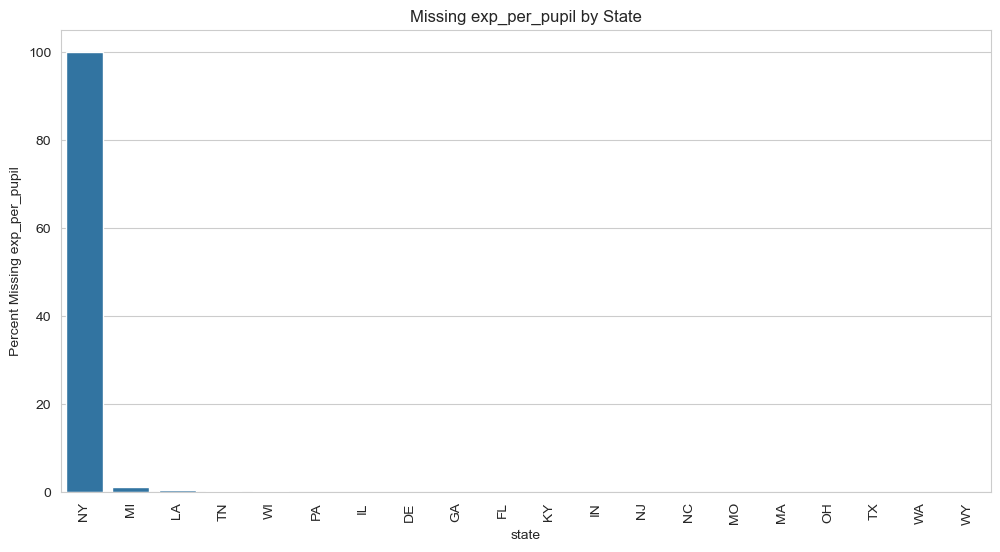

In [279]:
# Percent missing by state for exp_per_pupil
missing_by_state = merged_df.groupby('state')['exp_per_pupil'].apply(lambda x: x.isna().mean() * 100)
missing_by_state = missing_by_state.sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=missing_by_state.index, y=missing_by_state.values)
plt.xticks(rotation=90)
plt.ylabel('Percent Missing exp_per_pupil')
plt.title('Missing exp_per_pupil by State')
plt.show()

#### We are missing ~100% of New York (NY) exp_per_pupil record, almost all district finance data for NY is absent.

Any school from NY will have NaN for exp_per_pupil (and possibly enrollment).
Michigan (MI): small missingness (~2–3%) → likely minor impact.
All other states have complete finance data with no issues.
This pattern indicates missingness is not random, but highly state-specific. 

In [290]:
# Identify states with missing finance data
missing_by_state = (
    merged_df[merged_df['exp_per_pupil'].isna()]
    .groupby('state')
    .size()
    .reset_index(name='Schools with Missing exp_per_pupil')
)
missing_by_state['Percent of Total'] = (missing_by_state['Schools with Missing exp_per_pupil'] / len(merged_df) * 100).round(2)

In [291]:
display(missing_by_state)

,state,Schools with Missing exp_per_pupil,Percent of Total
0,IL,1,0.01
1,LA,1,0.01
2,NY,295,4.08
3,PA,1,0.01
4,TN,1,0.01
5,WI,1,0.01


In [292]:
states_to_impute = ['MI', 'LA', 'IL', 'PA', 'TN', 'WI']

In [293]:
for st in states_to_impute:
    exp_median = merged_df.loc[merged_df['state'] == st, 'exp_per_pupil'].median()
    enr_median = merged_df.loc[merged_df['state'] == st, 'enrollment'].median()

    merged_df.loc[(merged_df['state'] == st) & (merged_df['exp_per_pupil'].isna()), 'exp_per_pupil'] = exp_median
    merged_df.loc[(merged_df['state'] == st) & (merged_df['enrollment'].isna()), 'enrollment'] = enr_median

In [294]:
# Recheck missingness
missing_summary_after = (
    merged_df[['exp_per_pupil', 'enrollment']]
    .isna()
    .sum()
    .rename('Number Missing')
    .to_frame()
)

In [295]:
missing_summary_after['Percent Missing'] = (missing_summary_after['Number Missing'] / len(merged_df) * 100).round(2)

In [296]:
# Add note
ny_missing_count = merged_df[(merged_df['state'] == 'NY') & (merged_df['exp_per_pupil'].isna())].shape[0]
note = (
    f"⚠️ Note: {ny_missing_count} New York schools still have missing district finance data "
    "and remain as NaN because finance data for NY is completely unavailable. "
    "All other states' missing finance values have been imputed using state medians."
)

In [300]:
display(missing_summary_after)
display(note)

,Number Missing,Percent Missing
exp_per_pupil,295,4.08
enrollment,287,3.97


"⚠️ Note: 295 New York schools still have missing district finance data and remain as NaN because finance data for NY is completely unavailable. All other states' missing finance values have been imputed using state medians."

### The missingness is entirely state-specific (NY).
It’s not random, so filling it artificially would bias our EDA or modeling. To be thorough, we can confirm that all missing rows are indeed NY.

In [301]:
merged_df[merged_df['exp_per_pupil'].isna()]['state'].value_counts()

state
NY    295
Name: count, dtype: int64

#### Export a clean data set

In [302]:
merged_df.to_csv(
    'education_clean_new.csv',
    encoding='utf-8-sig',
    index=False
)

# Summary
1. We conducted quality control to fix column typos, drop redundant fields, and ensure correct data types.
2. We analyzed and handled missing finance data — imputing by state medians for MI, LA, IL, PA, TN, and WI, and retaining NY schools as NaN due to unavailable finance data.
3. We validated the final dataset for duplicates, data type accuracy, and numeric variable ranges, confirming readiness for exploratory data analysis (EDA).

# Load clean data

In [ ]:
merged_df = pd.read_csv(
    'https://raw.githubusercontent.com/princenewman02/Education/refs/heads/main/Code/education_clean.csv'
)

# Exploratory Data Analysis

### Examine distributions and relatioships
#### Plot the correlation matrix of the numerical variables in the training data to explore relationships between the variables

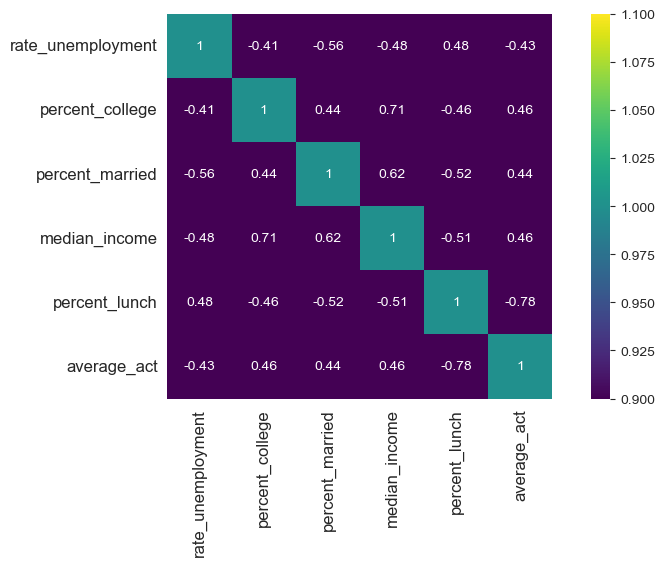

In [112]:
predictor_variables = ['rate_unemployment', 'percent_college', 'percent_married', 'median_income', 'percent_lunch'] 

numerical_predictors = df[predictor_variables].select_dtypes(include='number').columns.to_list()

corr_matrix = df[numerical_predictors + ["average_act"]].corr()

plt.figure(figsize=(10, 5))

sns.heatmap(
    corr_matrix, vmax=1, vmin=1, square=True, annot=True, cmap="viridis"
)

plt.tick_params(labelsize=12)

plt.show()

#### Make pair plot to explore relationships between the variables

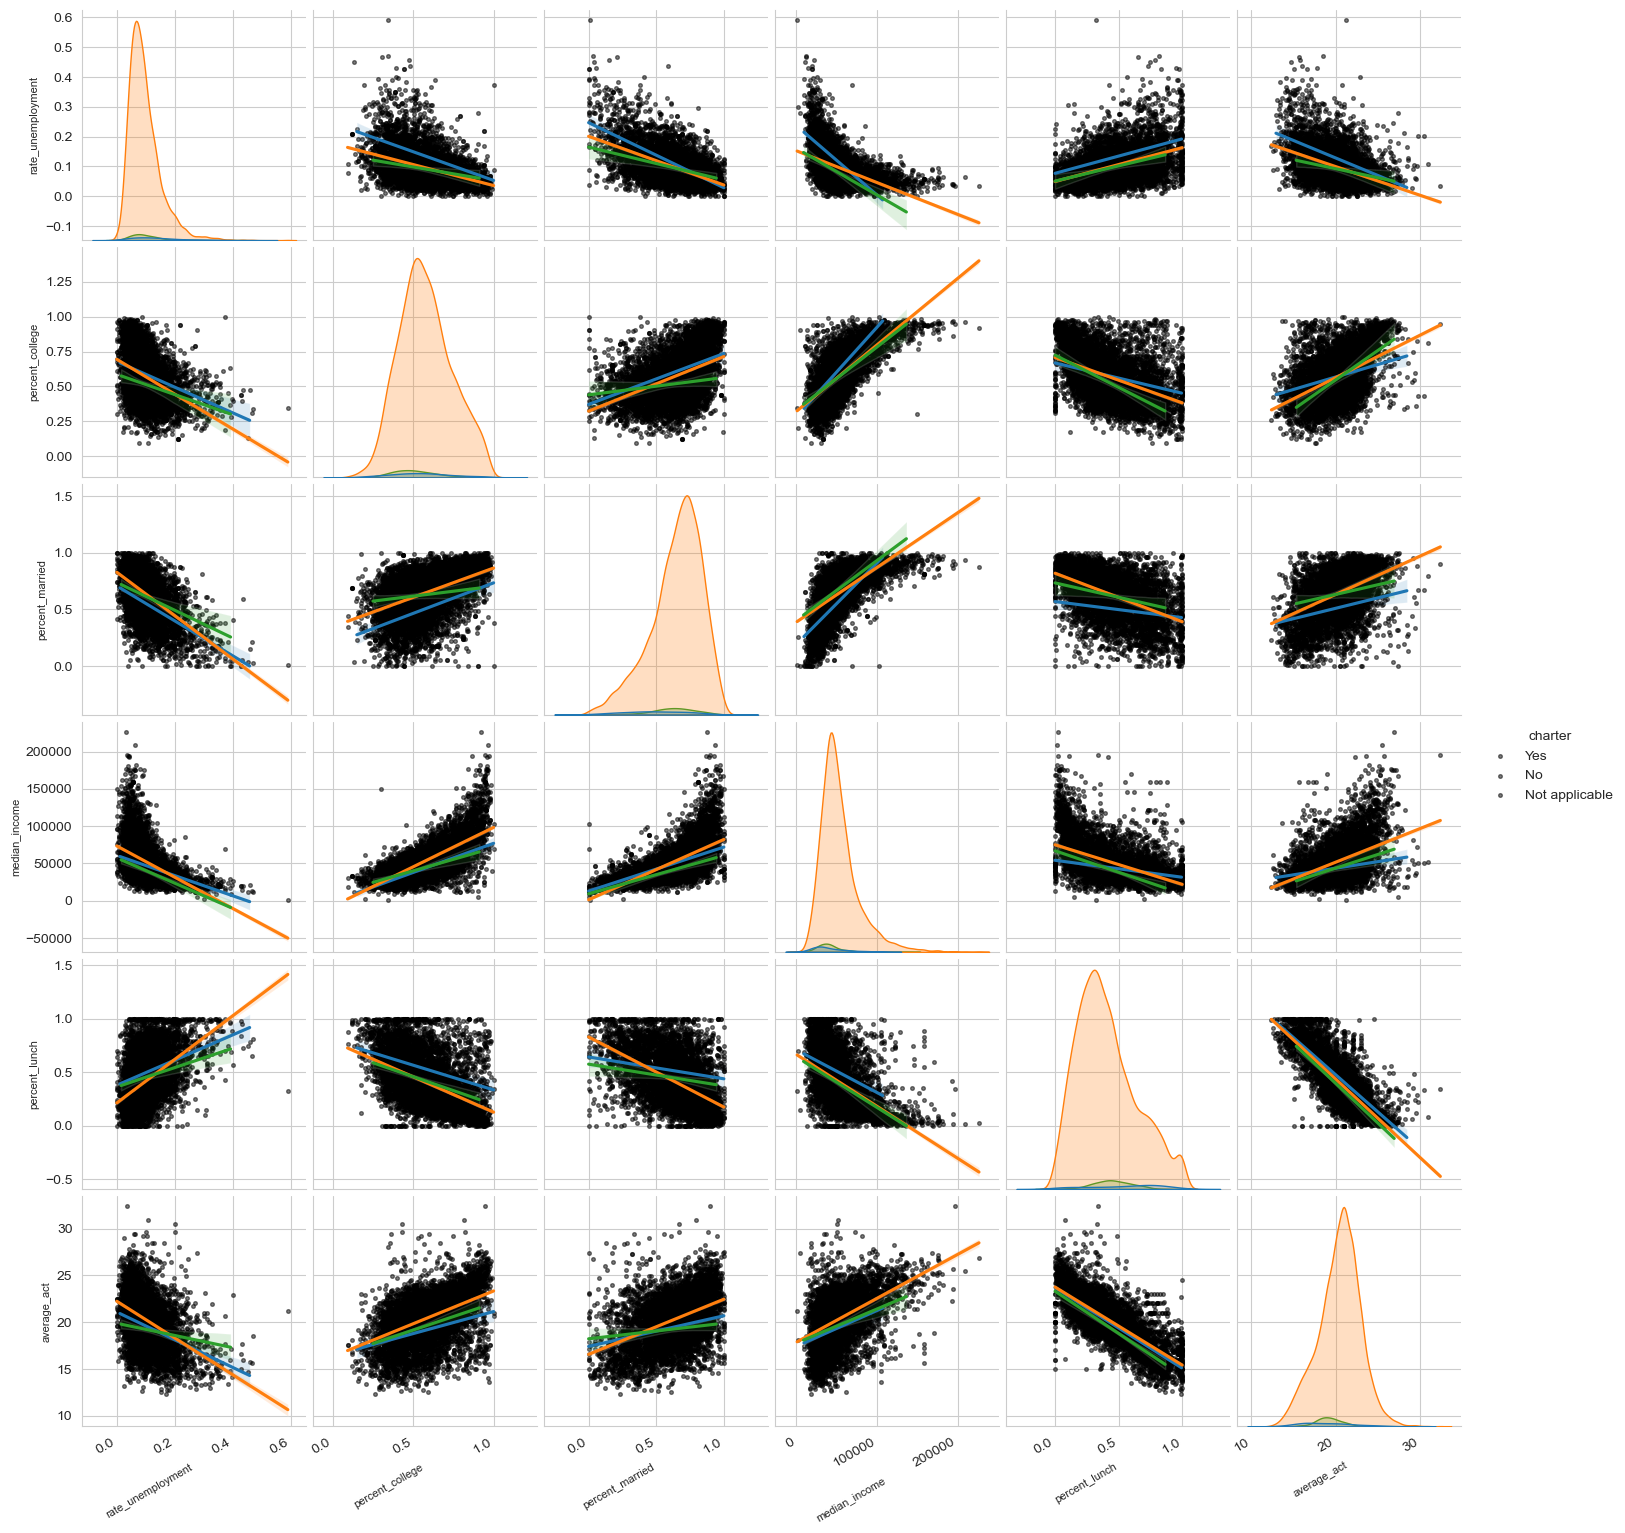

In [113]:
fig = sns.pairplot(
    data=df,
    vars=numerical_predictors + ['average_act'],
    hue='charter', 
    kind="reg",
    plot_kws={"scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    },
)

for ax in fig.axes.flat:
    if ax.get_xlabel() == 'CT Median Household Income':
        ax. ticklabel_format(style='sci', axis='x', scilimits=(0,0))      # Apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right')   # X-axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)     # Y-axis label size

    # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.show()

## Identify Outliers
We can use the interquartile range to identify outliers. This is also evident iin booxplots of the data. Median income is on a very different scale tha the other predictors, so we will make two plots to exploroee the data. 

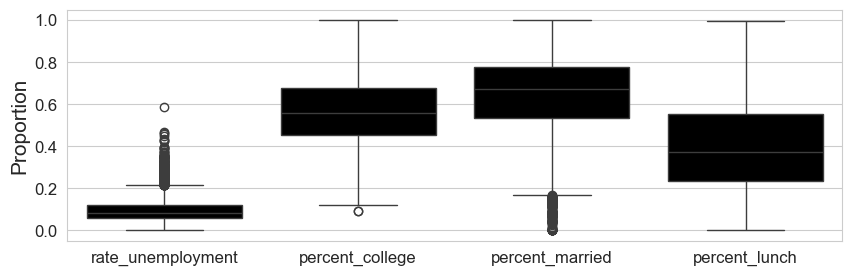

In [114]:
plt.figure (figsize=(10,3))

fractions = list(numerical_predictors)
fractions.remove('median_income')

sns.boxplot (data=df[fractions], color='k' )

plt.ylabel('Proportion', fontsize=15)

plt.tick_params(labelsize=12)

plt. show()

#### Look at the boxplot for the median income

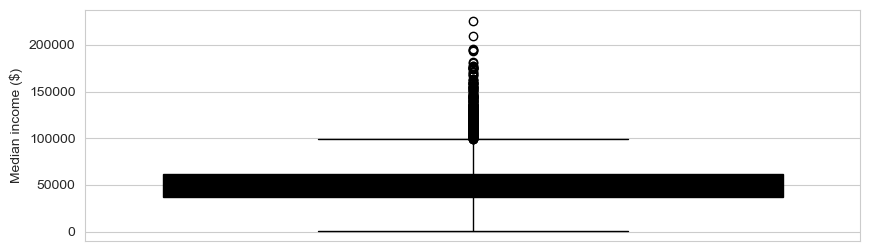

In [115]:
plt.figure (figsize=(10,3))

sns.boxplot(data=df, y='median_income', color='k' )

plt.ylabel('Median income ($)')

plt.show()

# Summary
1. The numerical predictors are related to average_act. The relationships appear roughly linear.
2. The numerical predictors are correlated with each other, suggesting that not all predictors will be necessary.
3. Some variables have skewed distributions, suggesting that transformations of input variables might be useful.
4. There are outliers in rate_unemployment, percent_college, percent_married and median_income. None of these are obviously incorrect values; they likely reflect skewed distributions. We may consider applying something like a log transformation to these predictors as we explore different models.
5. The relationships are similar across charter and non-charter schools, but might be significantly different.

# Modeling 

## Single input models 
Fit and assess models predicting the average ACT score from each of the input variables. You might try polynomial linear regression models, as appropriate. 

## Median income

#### Plot the regression line and the scatter plot 

In [ ]:
plt.figure